# Proyecto Módulo 7 - Segmentador Inteligente de Clientes Minoristas

## Introducción

Retail Insights S.A., consultora especializada en análisis para cadenas minoristas y e-commerce, requiere desarrollar un sistema de segmentación de clientes que permita identificar grupos de comportamiento relevantes a partir de datos no etiquetados. La necesidad surge porque actualmente solo se utilizan variables básicas, como edad o compras totales, lo que limita la identificación de patrones ocultos y la personalización de campañas de marketing.

En este contexto, el presente proyecto tiene como propósito aplicar técnicas de aprendizaje no supervisado para construir una segmentación de clientes útil, interpretable y escalable. Para ello, se trabajará con algoritmos de clusterización, técnicas de reducción dimensional y métricas de evaluación que permitan comparar resultados y proponer usos comerciales concretos.

## Objetivo del proyecto

Desarrollar un sistema de segmentación de clientes a partir de un dataset no etiquetado utilizando técnicas de aprendizaje no supervisado, con el fin de identificar patrones ocultos de comportamiento, visualizar los grupos detectados y generar insights aplicables a campañas de retención, fidelización y ventas cruzadas.

## Metodología general

El desarrollo del proyecto seguirá cinco etapas principales:

1. Fundamentos del aprendizaje no supervisado  
2. Técnicas de clusterización  
3. Reducción dimensional y preprocesamiento  
4. Aplicación práctica de clusterización con Python  
5. Evaluación final e interpretación de resultados  

## Lección 1 - Fundamentos del Aprendizaje No Supervisado



In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

# =========================================================
# CONFIGURACIÓN DE RUTAS
# =========================================================
RUTA_RAW = Path("../data/raw")
RUTA_INTERIM = Path("../data/interim")
RUTA_OUTPUTS = Path("../outputs")

RUTA_INTERIM.mkdir(parents=True, exist_ok=True)
RUTA_OUTPUTS.mkdir(parents=True, exist_ok=True)

# =========================================================
# BÚSQUEDA AUTOMÁTICA DEL DATASET CSV
# =========================================================
archivos_csv = sorted(RUTA_RAW.glob("*.csv"))

if not archivos_csv:
    raise FileNotFoundError(
        "No se encontró ningún archivo CSV en ../data/raw/. "
        "Copia ahí el dataset del proyecto y vuelve a ejecutar."
    )

ruta_dataset = archivos_csv[0]
print(f"Dataset detectado: {ruta_dataset.name}")

# =========================================================
# CARGA DEL DATASET
# =========================================================
df = pd.read_csv(ruta_dataset)

print("\n===== DIMENSIONES DEL DATASET =====")
print(df.shape)

print("\n===== PRIMERAS 5 FILAS =====")
display(df.head())

print("\n===== ÚLTIMAS 5 FILAS =====")
display(df.tail())

print("\n===== TIPOS DE DATOS =====")
display(df.dtypes.to_frame("tipo_dato"))

print("\n===== VALORES NULOS POR COLUMNA =====")
display(df.isna().sum().to_frame("nulos").sort_values(by="nulos", ascending=False))

print("\n===== ESTADÍSTICAS DESCRIPTIVAS =====")
display(df.describe(include="all").T)

# =========================================================
# SEPARACIÓN INICIAL DE VARIABLES
# =========================================================
variables_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
variables_categoricas = df.select_dtypes(exclude=[np.number]).columns.tolist()

resumen_variables = pd.DataFrame({
    "tipo_variable": (["Numérica"] * len(variables_numericas)) + (["Categórica"] * len(variables_categoricas)),
    "nombre_variable": variables_numericas + variables_categoricas
})

print("\n===== CLASIFICACIÓN DE VARIABLES =====")
display(resumen_variables)

print("\n===== RESUMEN INICIAL =====")
print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")
print(f"Variables numéricas: {len(variables_numericas)}")
print(f"Variables categóricas: {len(variables_categoricas)}")
print(f"Total de valores nulos en el dataset: {int(df.isna().sum().sum())}")

# =========================================================
# EXPORTAR RESUMEN DE NULOS Y TIPOS
# =========================================================
resumen_nulos = df.isna().sum().reset_index()
resumen_nulos.columns = ["columna", "nulos"]
resumen_nulos["tipo_dato"] = resumen_nulos["columna"].map(df.dtypes.astype(str).to_dict())

resumen_nulos.to_csv(RUTA_INTERIM / "resumen_inicial_dataset.csv", index=False)

print("\nArchivo guardado: ../data/interim/resumen_inicial_dataset.csv")

Dataset detectado: Test.csv

===== DIMENSIONES DEL DATASET =====
(2627, 11)

===== PRIMERAS 5 FILAS =====


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6,B
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6,A
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6,A
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6,B
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6,A



===== ÚLTIMAS 5 FILAS =====


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
2622,467954,Male,No,29,No,Healthcare,9.0,Low,4.0,Cat_6,B
2623,467958,Female,No,35,Yes,Doctor,1.0,Low,1.0,Cat_6,A
2624,467960,Female,No,53,Yes,Entertainment,NaN,Low,2.0,Cat_6,C
2625,467961,Male,Yes,47,Yes,Executive,1.0,High,5.0,Cat_4,C
2626,467968,Female,No,43,Yes,Healthcare,9.0,Low,3.0,Cat_7,A



===== TIPOS DE DATOS =====


...


===== ESTADÍSTICAS DESCRIPTIVAS =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2627.0,NaN,NaN,NaN,463433.918919,2618.245698,458989.0,461162.5,463379.0,465696.0,467968.0
Gender,2627,2,Male,1424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ever_Married,2577,2,Yes,1520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2627.0,NaN,NaN,NaN,43.649791,16.967015,18.0,30.0,41.0,53.0,89.0
Graduated,2603,2,Yes,1602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,2589,9,Artist,802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Work_Experience,2358.0,NaN,NaN,NaN,2.552587,3.341094,0.0,0.0,1.0,4.0,14.0
Spending_Score,2627,3,Low,1616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Family_Size,2514.0,NaN,NaN,NaN,2.825378,1.551906,1.0,2.0,2.0,4.0,9.0
Var_1,2595,7,Cat_6,1672,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== CLASIFICACIÓN DE VARIABLES =====


,tipo_variable,nombre_variable
0,Numérica,ID
1,Numérica,Age
2,Numérica,Work_Experience
3,Numérica,Family_Size
4,Categórica,Gender
5,Categórica,Ever_Married
6,Categórica,Graduated
7,Categórica,Profession
8,Categórica,Spending_Score
9,Categórica,Var_1



===== RESUMEN INICIAL =====
Cantidad de filas: 2627
Cantidad de columnas: 11
Variables numéricas: 4
Variables categóricas: 7
Total de valores nulos en el dataset: 526

Archivo guardado: ../data/interim/resumen_inicial_dataset.csv


### Hallazgos de la Lección 1

En esta primera etapa se estableció la base conceptual del proyecto, identificando las principales tareas del aprendizaje no supervisado y su pertinencia para un problema de segmentación de clientes. Además, se realizó una carga e inspección inicial del dataset, revisando dimensiones, tipos de variables, valores faltantes y estadísticas descriptivas preliminares. Esta revisión inicial permite comprender la estructura general de los datos y preparar el terreno para las siguientes etapas de preprocesamiento, reducción dimensional y clusterización.

## Lección 2 - Técnicas de Clusterización

In [2]:
from pathlib import Path
import pandas as pd

RUTA_RAW = Path("../data/raw")
archivos_csv = sorted(RUTA_RAW.glob("*.csv"))

if not archivos_csv:
    raise FileNotFoundError("No se encontró ningún archivo CSV en ../data/raw/")

ruta_dataset = archivos_csv[0]
df = pd.read_csv(ruta_dataset)

print(f"Dataset cargado: {ruta_dataset.name}")
print(df.shape)

Dataset cargado: Test.csv
(2627, 11)


In [3]:
import pandas as pd

# =========================================================
# COMPARACIÓN TEÓRICA DE ALGORITMOS DE CLUSTERIZACIÓN
# =========================================================
comparacion_algoritmos = pd.DataFrame([
    {
        "algoritmo": "K-Means",
        "requiere_numero_clusteres": "Sí",
        "detecta_ruido_outliers": "No directamente",
        "tipo_de_grupos_que_modela_mejor": "Grupos compactos y aproximadamente esféricos",
        "ventaja_principal": "Rápido, simple e interpretable",
        "desventaja_principal": "Sensible a outliers y requiere definir k",
        "uso_en_este_proyecto": "Modelo base de segmentación"
    },
    {
        "algoritmo": "DBSCAN",
        "requiere_numero_clusteres": "No",
        "detecta_ruido_outliers": "Sí",
        "tipo_de_grupos_que_modela_mejor": "Grupos de forma arbitraria por densidad",
        "ventaja_principal": "Identifica ruido y no exige fijar k",
        "desventaja_principal": "Sensible a eps y min_samples",
        "uso_en_este_proyecto": "Detección de grupos densos y observaciones atípicas"
    },
    {
        "algoritmo": "Jerárquico",
        "requiere_numero_clusteres": "No inicialmente",
        "detecta_ruido_outliers": "No directamente",
        "tipo_de_grupos_que_modela_mejor": "Estructuras jerárquicas y relaciones progresivas",
        "ventaja_principal": "Permite explorar relaciones con dendrograma",
        "desventaja_principal": "Mayor costo computacional",
        "uso_en_este_proyecto": "Apoyo visual e interpretación estructural"
    }
])

print("===== COMPARACIÓN DE ALGORITMOS =====")
display(comparacion_algoritmos)

# =========================================================
# DEFINICIÓN PRELIMINAR DE COLUMNAS PARA MODELADO
# =========================================================
columnas_excluir_modelo = ["ID", "Segmentation"]
columnas_candidatas = [col for col in df.columns if col not in columnas_excluir_modelo]

resumen_modelado = pd.DataFrame({
    "columna": df.columns,
    "usar_en_modelado": [col in columnas_candidatas for col in df.columns],
    "comentario": [
        "Identificador, excluir" if col == "ID"
        else "Etiqueta externa, no usar para clustering" if col == "Segmentation"
        else "Candidata para preprocesamiento y clustering"
        for col in df.columns
    ]
})

print("\n===== COLUMNAS CANDIDATAS PARA CLUSTERING =====")
display(resumen_modelado)

resumen_modelado.to_csv("../data/interim/columnas_candidatas_clusterizacion.csv", index=False)
print("\nArchivo guardado: ../data/interim/columnas_candidatas_clusterizacion.csv")

===== COMPARACIÓN DE ALGORITMOS =====


,algoritmo,requiere_numero_clusteres,detecta_ruido_outliers,tipo_de_grupos_que_modela_mejor,ventaja_principal,desventaja_principal,uso_en_este_proyecto
0,K-Means,Sí,No directamente,Grupos compactos y aproximadamente esféricos,"Rápido, simple e interpretable",Sensible a outliers y requiere definir k,Modelo base de segmentación
1,DBSCAN,No,Sí,Grupos de forma arbitraria por densidad,Identifica ruido y no exige fijar k,Sensible a eps y min_samples,Detección de grupos densos y observaciones atí...
2,Jerárquico,No inicialmente,No directamente,Estructuras jerárquicas y relaciones progresivas,Permite explorar relaciones con dendrograma,Mayor costo computacional,Apoyo visual e interpretación estructural



===== COLUMNAS CANDIDATAS PARA CLUSTERING =====


,columna,usar_en_modelado,comentario
0,ID,False,"Identificador, excluir"
1,Gender,True,Candidata para preprocesamiento y clustering
2,Ever_Married,True,Candidata para preprocesamiento y clustering
3,Age,True,Candidata para preprocesamiento y clustering
4,Graduated,True,Candidata para preprocesamiento y clustering
5,Profession,True,Candidata para preprocesamiento y clustering
6,Work_Experience,True,Candidata para preprocesamiento y clustering
7,Spending_Score,True,Candidata para preprocesamiento y clustering
8,Family_Size,True,Candidata para preprocesamiento y clustering
9,Var_1,True,Candidata para preprocesamiento y clustering



Archivo guardado: ../data/interim/columnas_candidatas_clusterizacion.csv


### Hallazgos de la Lección 2

En esta etapa se analizaron las principales técnicas de clusterización relevantes para el proyecto, comparando sus fortalezas, limitaciones y escenarios de uso. A nivel metodológico, se concluyó que K-Means servirá como modelo base de segmentación, DBSCAN será útil para identificar densidades y posibles anomalías, y el agrupamiento jerárquico aportará una lectura estructural complementaria mediante dendrogramas. Además, se definió que las columnas `ID` y `Segmentation` no deben utilizarse en el modelado no supervisado, ya que corresponden respectivamente a un identificador técnico y a una etiqueta externa que rompería la lógica del clustering.

## Lección 3 - Reducción Dimensional y Preprocesamiento

===== DIMENSIONES ORIGINALES =====
(2627, 11)

===== COLUMNAS USADAS PARA MODELADO =====
['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1']

===== VARIABLES NUMÉRICAS =====
['Age', 'Work_Experience', 'Family_Size', 'Spending_Score_Ordinal']

===== VARIABLES CATEGÓRICAS =====
['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Var_1']

===== RESUMEN DE OUTLIERS TRATADOS =====


,variable,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers_detectados
0,Age,30.0,53.0,23.0,-4.5,87.5,19
1,Work_Experience,0.0,4.0,4.0,-6.0,10.0,58
2,Family_Size,2.0,4.0,2.0,-1.0,7.0,31
3,Spending_Score_Ordinal,0.0,1.0,1.0,-1.5,2.5,0



===== MATRIZ PREPROCESADA =====
(2627, 26)


,Age,Work_Experience,Family_Size,Spending_Score_Ordinal,Gender_Female,Gender_Male,Ever_Married_No,Ever_Married_Yes,Graduated_No,Graduated_Yes,...,Profession_Homemaker,Profession_Lawyer,Profession_Marketing,Var_1_Cat_1,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7
0,-0.451029,-0.771927,-1.208229,-0.721759,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.392012,1.873241,0.837325,0.635478,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.496528,-0.771927,-1.208229,-0.721759,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.906359,2.534533,-0.526378,1.992715,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-1.454315,-0.441281,0.837325,-0.721759,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0



===== RESULTADOS PCA =====
Varianza explicada por PCA1: 0.2755
Varianza explicada por PCA2: 0.1766
Varianza explicada acumulada: 0.4522

===== RESULTADOS t-SNE =====
t-SNE ejecutado correctamente sobre la matriz preprocesada.


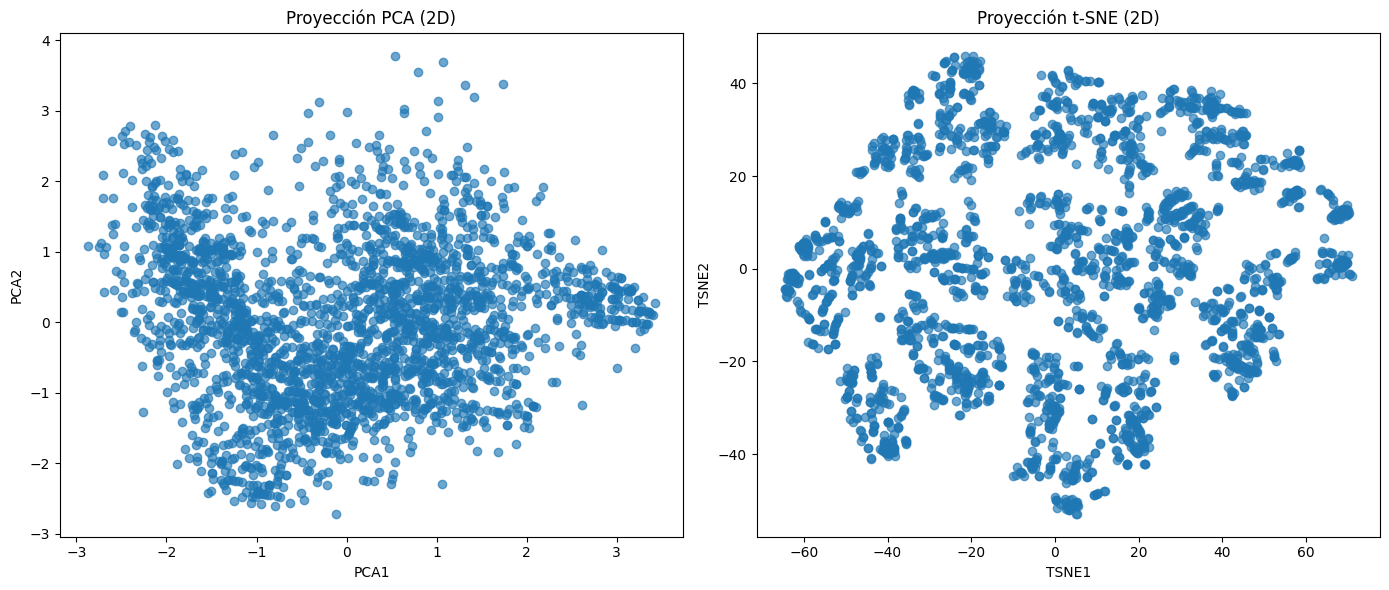


===== RESUMEN FINAL DE LA LECCIÓN 3 =====
Dimensiones originales del dataset de modelado: (2627, 9)
Dimensiones tras preprocesamiento: (2627, 26)
Varianza explicada acumulada por PCA (2 componentes): 0.4522
Archivo guardado: ../data/interim/dataset_preprocesado_leccion3.csv
Archivo guardado: ../data/interim/proyeccion_pca_2d.csv
Archivo guardado: ../data/interim/proyeccion_tsne_2d.csv
Archivo guardado: ../data/interim/resumen_outliers_leccion3.csv
Gráfico guardado: ../outputs/comparacion_pca_tsne.png


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# =========================================================
# CONFIGURACIÓN
# =========================================================
RUTA_INTERIM = Path("../data/interim")
RUTA_OUTPUTS = Path("../outputs")
RUTA_INTERIM.mkdir(parents=True, exist_ok=True)
RUTA_OUTPUTS.mkdir(parents=True, exist_ok=True)

# Si no existe df en memoria, volver a cargar el CSV detectado
if "df" not in globals():
    archivos_csv = sorted(Path("../data/raw").glob("*.csv"))
    if not archivos_csv:
        raise FileNotFoundError("No se encontró ningún CSV en ../data/raw/")
    df = pd.read_csv(archivos_csv[0])

df_l3 = df.copy()

print("===== DIMENSIONES ORIGINALES =====")
print(df_l3.shape)

# =========================================================
# 1) EXCLUSIÓN DE COLUMNAS NO APTAS PARA CLUSTERING
# =========================================================
columnas_excluir = ["ID", "Segmentation"]
df_modelo = df_l3.drop(columns=columnas_excluir, errors="ignore").copy()

print("\n===== COLUMNAS USADAS PARA MODELADO =====")
print(df_modelo.columns.tolist())

# =========================================================
# 2) DEFINICIÓN DE VARIABLES
# =========================================================
# Spending_Score tiene orden natural: Low < Average < High
mapa_spending = {"Low": 0, "Average": 1, "High": 2}
if "Spending_Score" in df_modelo.columns:
    df_modelo["Spending_Score_Ordinal"] = df_modelo["Spending_Score"].map(mapa_spending)
    df_modelo = df_modelo.drop(columns=["Spending_Score"])

variables_numericas = ["Age", "Work_Experience", "Family_Size", "Spending_Score_Ordinal"]
variables_numericas = [col for col in variables_numericas if col in df_modelo.columns]

variables_categoricas = [col for col in df_modelo.columns if col not in variables_numericas]

print("\n===== VARIABLES NUMÉRICAS =====")
print(variables_numericas)

print("\n===== VARIABLES CATEGÓRICAS =====")
print(variables_categoricas)

# =========================================================
# 3) TRATAMIENTO BÁSICO DE OUTLIERS EN NUMÉRICAS (CAPPING IQR)
# =========================================================
resumen_outliers = []

for col in variables_numericas:
    serie = df_modelo[col].copy()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr

    cantidad_outliers = ((serie < li) | (serie > ls)).sum()

    df_modelo[col] = serie.clip(lower=li, upper=ls)

    resumen_outliers.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": li,
        "limite_superior": ls,
        "cantidad_outliers_detectados": int(cantidad_outliers)
    })

df_outliers = pd.DataFrame(resumen_outliers)

print("\n===== RESUMEN DE OUTLIERS TRATADOS =====")
display(df_outliers.round(3))

df_outliers.to_csv(RUTA_INTERIM / "resumen_outliers_leccion3.csv", index=False)

# =========================================================
# 4) PREPROCESAMIENTO: IMPUTACIÓN + CODIFICACIÓN + ESCALADO
# =========================================================
def crear_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

pipeline_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipeline_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", crear_onehot_encoder())
])

preprocesador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, variables_numericas),
        ("cat", pipeline_categorico, variables_categoricas)
    ]
)

X_preprocesado = preprocesador.fit_transform(df_modelo)

# Convertir a array si fuese sparse
if hasattr(X_preprocesado, "toarray"):
    X_preprocesado = X_preprocesado.toarray()

# =========================================================
# 5) NOMBRE DE FEATURES TRANSFORMADAS
# =========================================================
feature_names_num = variables_numericas

encoder_cat = preprocesador.named_transformers_["cat"].named_steps["onehot"]
feature_names_cat = encoder_cat.get_feature_names_out(variables_categoricas).tolist()

feature_names = feature_names_num + feature_names_cat

X_df = pd.DataFrame(X_preprocesado, columns=feature_names)

print("\n===== MATRIZ PREPROCESADA =====")
print(X_df.shape)
display(X_df.head())

X_df.to_csv(RUTA_INTERIM / "dataset_preprocesado_leccion3.csv", index=False)

# =========================================================
# 6) PCA
# =========================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_preprocesado)

pca_df = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])

if "Segmentation" in df_l3.columns:
    pca_df["Segmentation_ref"] = df_l3["Segmentation"].values

varianza_explicada = pca.explained_variance_ratio_
varianza_total = varianza_explicada.sum()

print("\n===== RESULTADOS PCA =====")
print(f"Varianza explicada por PCA1: {varianza_explicada[0]:.4f}")
print(f"Varianza explicada por PCA2: {varianza_explicada[1]:.4f}")
print(f"Varianza explicada acumulada: {varianza_total:.4f}")

pca_df.to_csv(RUTA_INTERIM / "proyeccion_pca_2d.csv", index=False)

# =========================================================
# 7) t-SNE
# =========================================================
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_preprocesado)

tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])

if "Segmentation" in df_l3.columns:
    tsne_df["Segmentation_ref"] = df_l3["Segmentation"].values

tsne_df.to_csv(RUTA_INTERIM / "proyeccion_tsne_2d.csv", index=False)

print("\n===== RESULTADOS t-SNE =====")
print("t-SNE ejecutado correctamente sobre la matriz preprocesada.")

# =========================================================
# 8) VISUALIZACIÓN COMPARATIVA PCA vs t-SNE
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if "Segmentation" in pca_df.columns:
    categorias = sorted(pca_df["Segmentation_ref"].dropna().unique())
    for cat in categorias:
        mask = pca_df["Segmentation_ref"] == cat
        axes[0].scatter(
            pca_df.loc[mask, "PCA1"],
            pca_df.loc[mask, "PCA2"],
            alpha=0.65,
            label=str(cat)
        )
    axes[0].legend(title="Referencia")
else:
    axes[0].scatter(pca_df["PCA1"], pca_df["PCA2"], alpha=0.65)

axes[0].set_title("Proyección PCA (2D)")
axes[0].set_xlabel("PCA1")
axes[0].set_ylabel("PCA2")

if "Segmentation" in tsne_df.columns:
    categorias = sorted(tsne_df["Segmentation_ref"].dropna().unique())
    for cat in categorias:
        mask = tsne_df["Segmentation_ref"] == cat
        axes[1].scatter(
            tsne_df.loc[mask, "TSNE1"],
            tsne_df.loc[mask, "TSNE2"],
            alpha=0.65,
            label=str(cat)
        )
    axes[1].legend(title="Referencia")
else:
    axes[1].scatter(tsne_df["TSNE1"], tsne_df["TSNE2"], alpha=0.65)

axes[1].set_title("Proyección t-SNE (2D)")
axes[1].set_xlabel("TSNE1")
axes[1].set_ylabel("TSNE2")

plt.tight_layout()
plt.savefig(RUTA_OUTPUTS / "comparacion_pca_tsne.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 9) RESUMEN FINAL
# =========================================================
print("\n===== RESUMEN FINAL DE LA LECCIÓN 3 =====")
print(f"Dimensiones originales del dataset de modelado: {df_modelo.shape}")
print(f"Dimensiones tras preprocesamiento: {X_df.shape}")
print(f"Varianza explicada acumulada por PCA (2 componentes): {varianza_total:.4f}")
print("Archivo guardado: ../data/interim/dataset_preprocesado_leccion3.csv")
print("Archivo guardado: ../data/interim/proyeccion_pca_2d.csv")
print("Archivo guardado: ../data/interim/proyeccion_tsne_2d.csv")
print("Archivo guardado: ../data/interim/resumen_outliers_leccion3.csv")
print("Gráfico guardado: ../outputs/comparacion_pca_tsne.png")

### Hallazgos de la Lección 3

En esta etapa se preprocesó el dataset excluyendo variables no aptas para el modelado no supervisado, tratando valores faltantes, aplicando codificación de variables categóricas, escalamiento y un tratamiento básico de outliers sobre las variables numéricas. Posteriormente, se aplicaron dos técnicas de reducción dimensional: PCA y t-SNE.

PCA permitió proyectar la información en un espacio bidimensional conservando una fracción explícita de la varianza total, lo que resulta útil para resumir la estructura general de los datos. Por su parte, t-SNE ofreció una representación más flexible para observar vecindades y posibles agrupamientos locales, aunque sin una interpretación directa en términos de varianza explicada. En consecuencia, PCA se considerará especialmente útil para síntesis estructural y t-SNE para exploración visual de posibles segmentos.

## Lección 4 - Aplicación práctica de Clusterización con Python

===== DIMENSIONES DE LA MATRIZ PARA CLUSTERING =====
(2627, 26)

===== EVALUACIÓN K-MEANS =====


,k,inertia,silhouette
0,2,14360.1527,0.1849
1,3,12499.0649,0.1951
2,4,10953.7786,0.1884
3,5,10177.9841,0.1743
4,6,9564.9344,0.1657
5,7,9147.9368,0.1671
6,8,8784.3914,0.1645



Número óptimo de clústeres sugerido por silueta: 3

===== PARÁMETROS DBSCAN =====
min_samples: 10
eps seleccionado: 1.9878
percentil usado en k-distance: 90
Cantidad de clústeres DBSCAN (sin ruido): 1
Proporción de ruido: 0.0179

===== RESUMEN COMPARATIVO DE ALGORITMOS =====


,algoritmo,n_clusters,silhouette,observaciones_ruido_pct
0,K-Means,3,0.1951,0.0000
1,Jerárquico,3,0.1680,0.0000
2,DBSCAN,1,NaN,0.0179


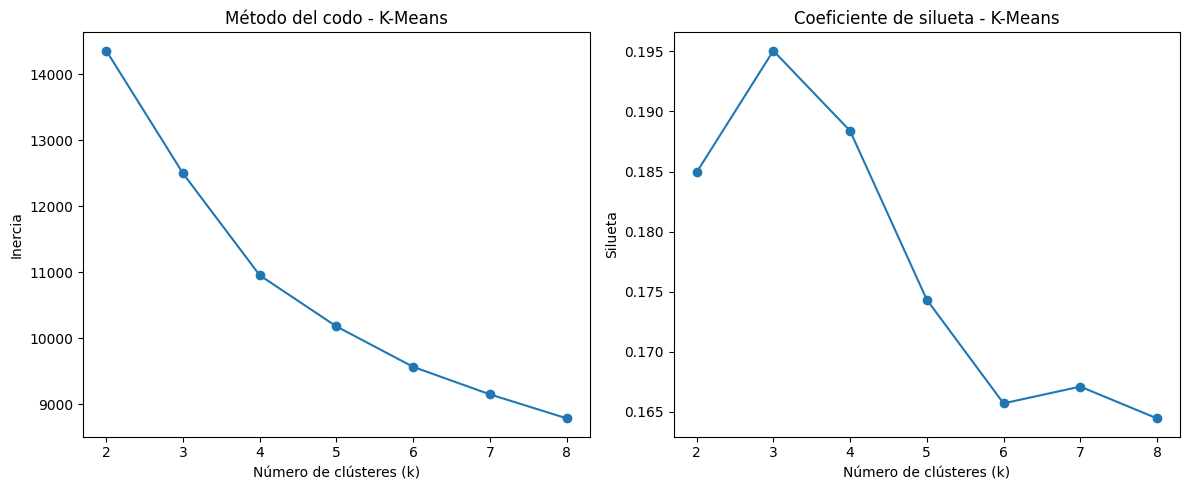

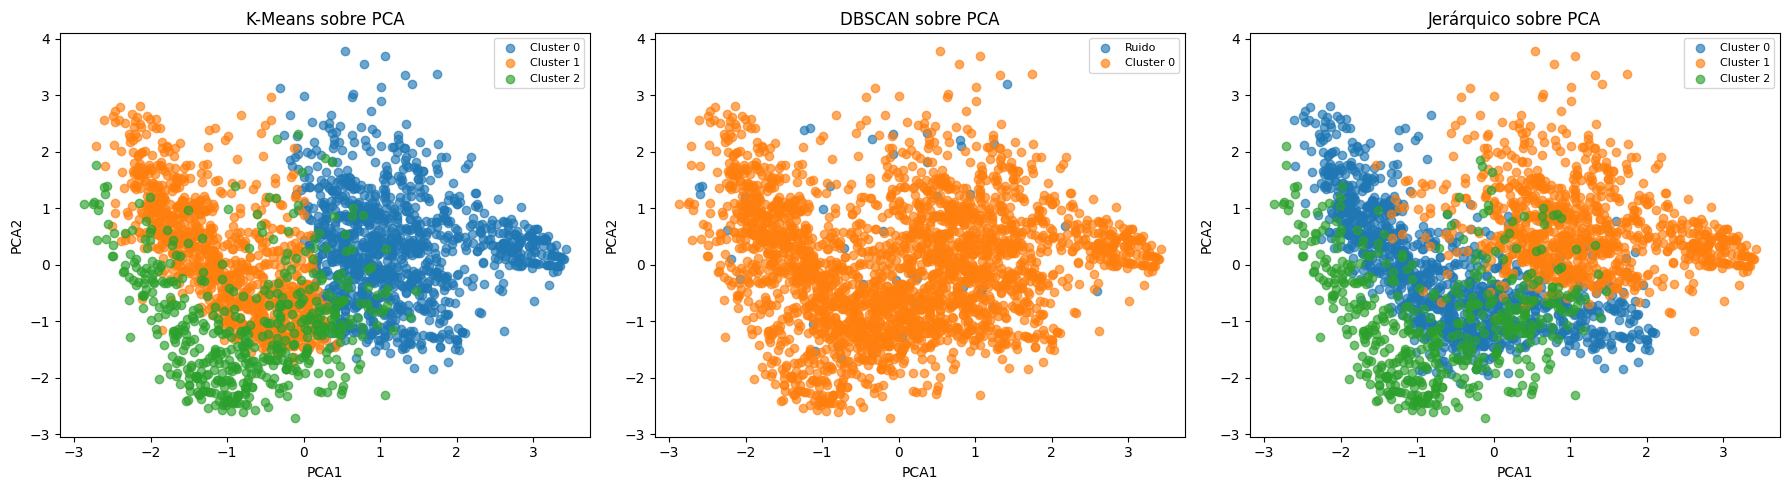

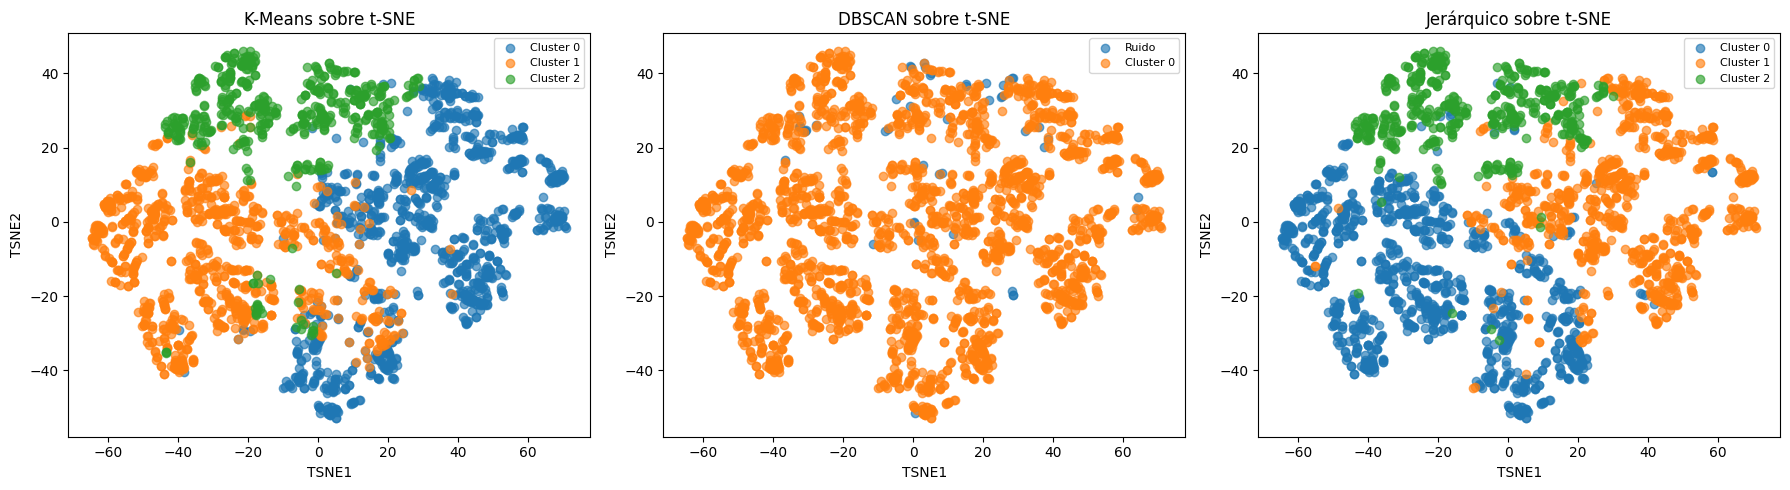

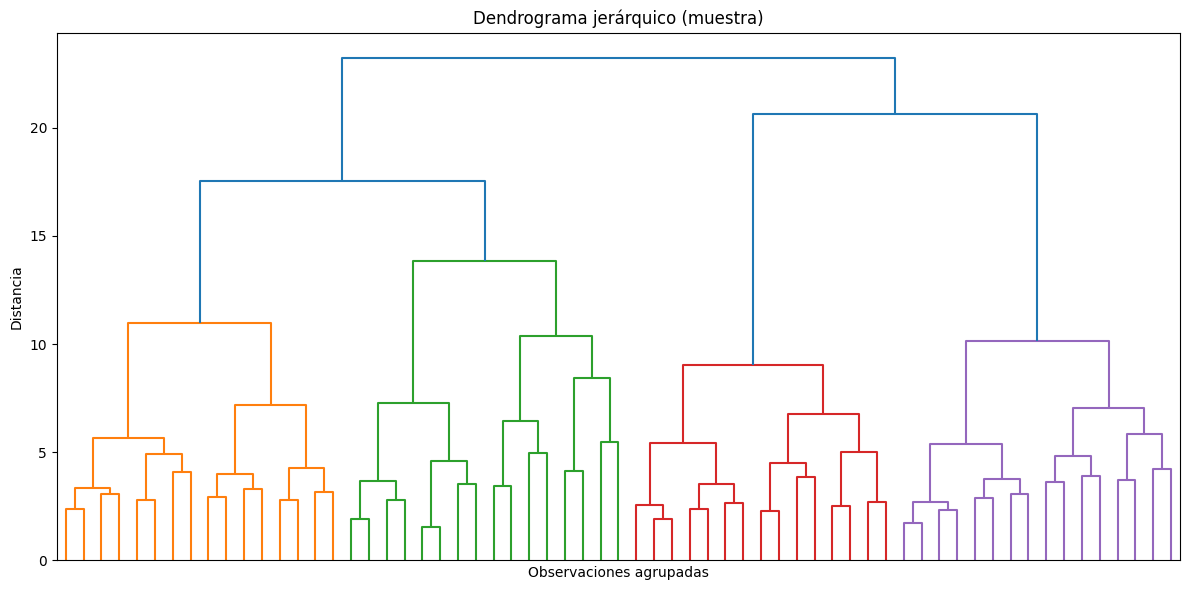


===== RESUMEN FINAL DE LA LECCIÓN 4 =====
k óptimo sugerido para K-Means: 3
Silueta K-Means: 0.1951
Silueta Jerárquico: 0.1680
Silueta DBSCAN: no disponible
Cantidad de clústeres DBSCAN (sin ruido): 1
Proporción de ruido DBSCAN: 0.0179
Archivo guardado: ../data/interim/evaluacion_kmeans_codo_silueta.csv
Archivo guardado: ../data/interim/resumen_algoritmos_clusterizacion.csv
Archivo guardado: ../data/interim/dataset_con_clusters_leccion4.csv
Gráfico guardado: ../outputs/kmeans_codo_silueta.png
Gráfico guardado: ../outputs/clusters_pca_algoritmos.png
Gráfico guardado: ../outputs/clusters_tsne_algoritmos.png
Gráfico guardado: ../outputs/dendrograma_jerarquico.png


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

# =========================================================
# CONFIGURACIÓN
# =========================================================
RUTA_INTERIM = Path("../data/interim")
RUTA_OUTPUTS = Path("../outputs")
RUTA_INTERIM.mkdir(parents=True, exist_ok=True)
RUTA_OUTPUTS.mkdir(parents=True, exist_ok=True)

# Recuperar objetos desde memoria o desde archivos
if "df_l3" in globals():
    df_base = df_l3.copy()
else:
    archivos_csv = sorted(Path("../data/raw").glob("*.csv"))
    if not archivos_csv:
        raise FileNotFoundError("No se encontró ningún CSV en ../data/raw/")
    df_base = pd.read_csv(archivos_csv[0])

if "X_preprocesado" in globals():
    X_cluster = X_preprocesado.copy()
else:
    X_cluster = pd.read_csv(RUTA_INTERIM / "dataset_preprocesado_leccion3.csv").values

if "pca_df" in globals():
    df_pca_plot = pca_df.copy()
else:
    df_pca_plot = pd.read_csv(RUTA_INTERIM / "proyeccion_pca_2d.csv")

if "tsne_df" in globals():
    df_tsne_plot = tsne_df.copy()
else:
    df_tsne_plot = pd.read_csv(RUTA_INTERIM / "proyeccion_tsne_2d.csv")

print("===== DIMENSIONES DE LA MATRIZ PARA CLUSTERING =====")
print(X_cluster.shape)

# =========================================================
# 1) MÉTODO DEL CODO + SILUETA PARA K-MEANS
# =========================================================
k_range = list(range(2, 9))
resultados_kmeans = []

for k in k_range:
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = modelo_k.fit_predict(X_cluster)

    inertia = modelo_k.inertia_
    sil = silhouette_score(X_cluster, labels_k)

    resultados_kmeans.append({
        "k": k,
        "inertia": inertia,
        "silhouette": sil
    })

df_kmeans_eval = pd.DataFrame(resultados_kmeans)

# elegir k óptimo por mayor silhouette
k_optimo = int(df_kmeans_eval.loc[df_kmeans_eval["silhouette"].idxmax(), "k"])

print("\n===== EVALUACIÓN K-MEANS =====")
display(df_kmeans_eval.round(4))
print(f"\nNúmero óptimo de clústeres sugerido por silueta: {k_optimo}")

df_kmeans_eval.to_csv(RUTA_INTERIM / "evaluacion_kmeans_codo_silueta.csv", index=False)

# =========================================================
# 2) AJUSTE FINAL DE K-MEANS
# =========================================================
modelo_kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=20)
labels_kmeans = modelo_kmeans.fit_predict(X_cluster)

sil_kmeans = silhouette_score(X_cluster, labels_kmeans)
n_clusters_kmeans = len(np.unique(labels_kmeans))

# =========================================================
# 3) AJUSTE DE CLUSTERING JERÁRQUICO
# =========================================================
modelo_jer = AgglomerativeClustering(n_clusters=k_optimo, linkage="ward")
labels_jer = modelo_jer.fit_predict(X_cluster)

sil_jer = silhouette_score(X_cluster, labels_jer)
n_clusters_jer = len(np.unique(labels_jer))

# =========================================================
# 4) AJUSTE DE DBSCAN CON BÚSQUEDA SIMPLE DE eps
# =========================================================
min_samples = 10

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_cluster)
distancias, _ = nn.kneighbors(X_cluster)
kdist = np.sort(distancias[:, -1])

percentiles_eps = [80, 85, 90, 92, 95, 97]
mejor_dbscan = None
mejor_sil_db = -np.inf

for p in percentiles_eps:
    eps_candidato = float(np.percentile(kdist, p))
    modelo_db = DBSCAN(eps=eps_candidato, min_samples=min_samples)
    labels_db = modelo_db.fit_predict(X_cluster)

    mask_validos = labels_db != -1
    clusters_validos = set(labels_db[mask_validos])

    if len(clusters_validos) >= 2 and mask_validos.sum() > 10:
        sil_db = silhouette_score(X_cluster[mask_validos], labels_db[mask_validos])

        if sil_db > mejor_sil_db:
            mejor_sil_db = sil_db
            mejor_dbscan = {
                "eps": eps_candidato,
                "percentil": p,
                "labels": labels_db.copy(),
                "silhouette": sil_db
            }

# fallback si DBSCAN no logra una estructura adecuada
if mejor_dbscan is None:
    eps_fallback = float(np.percentile(kdist, 90))
    modelo_dbscan = DBSCAN(eps=eps_fallback, min_samples=min_samples)
    labels_dbscan = modelo_dbscan.fit_predict(X_cluster)
    mask_validos = labels_dbscan != -1

    if len(set(labels_dbscan[mask_validos])) >= 2 and mask_validos.sum() > 10:
        sil_dbscan = silhouette_score(X_cluster[mask_validos], labels_dbscan[mask_validos])
    else:
        sil_dbscan = np.nan

    eps_final = eps_fallback
    percentil_final = 90
else:
    labels_dbscan = mejor_dbscan["labels"]
    sil_dbscan = mejor_dbscan["silhouette"]
    eps_final = mejor_dbscan["eps"]
    percentil_final = mejor_dbscan["percentil"]

clusters_dbscan = sorted([x for x in np.unique(labels_dbscan) if x != -1])
n_clusters_dbscan = len(clusters_dbscan)
proporcion_ruido = float((labels_dbscan == -1).mean())

print("\n===== PARÁMETROS DBSCAN =====")
print(f"min_samples: {min_samples}")
print(f"eps seleccionado: {eps_final:.4f}")
print(f"percentil usado en k-distance: {percentil_final}")
print(f"Cantidad de clústeres DBSCAN (sin ruido): {n_clusters_dbscan}")
print(f"Proporción de ruido: {proporcion_ruido:.4f}")

# =========================================================
# 5) RESUMEN COMPARATIVO DE ALGORITMOS
# =========================================================
resumen_algoritmos = pd.DataFrame([
    {
        "algoritmo": "K-Means",
        "n_clusters": n_clusters_kmeans,
        "silhouette": sil_kmeans,
        "observaciones_ruido_pct": 0.0
    },
    {
        "algoritmo": "Jerárquico",
        "n_clusters": n_clusters_jer,
        "silhouette": sil_jer,
        "observaciones_ruido_pct": 0.0
    },
    {
        "algoritmo": "DBSCAN",
        "n_clusters": n_clusters_dbscan,
        "silhouette": sil_dbscan,
        "observaciones_ruido_pct": proporcion_ruido
    }
])

print("\n===== RESUMEN COMPARATIVO DE ALGORITMOS =====")
display(resumen_algoritmos.round(4))

resumen_algoritmos.to_csv(RUTA_INTERIM / "resumen_algoritmos_clusterizacion.csv", index=False)

# =========================================================
# 6) GUARDAR ETIQUETAS DE CLUSTER
# =========================================================
df_clusters = df_base.copy()
df_clusters["cluster_kmeans"] = labels_kmeans
df_clusters["cluster_jerarquico"] = labels_jer
df_clusters["cluster_dbscan"] = labels_dbscan

df_clusters.to_csv(RUTA_INTERIM / "dataset_con_clusters_leccion4.csv", index=False)

# =========================================================
# 7) VISUALIZACIÓN: MÉTODO DEL CODO Y SILUETA
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(df_kmeans_eval["k"], df_kmeans_eval["inertia"], marker="o")
axes[0].set_title("Método del codo - K-Means")
axes[0].set_xlabel("Número de clústeres (k)")
axes[0].set_ylabel("Inercia")

axes[1].plot(df_kmeans_eval["k"], df_kmeans_eval["silhouette"], marker="o")
axes[1].set_title("Coeficiente de silueta - K-Means")
axes[1].set_xlabel("Número de clústeres (k)")
axes[1].set_ylabel("Silueta")

plt.tight_layout()
plt.savefig(RUTA_OUTPUTS / "kmeans_codo_silueta.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 8) FUNCIÓN PARA GRAFICAR CLÚSTERES EN 2D
# =========================================================
def graficar_clusters(df_plot, x_col, y_col, labels, titulo, ax):
    labels_unicos = sorted(pd.Series(labels).unique())
    for lab in labels_unicos:
        mask = pd.Series(labels) == lab
        etiqueta = "Ruido" if lab == -1 else f"Cluster {lab}"
        ax.scatter(
            df_plot.loc[mask, x_col],
            df_plot.loc[mask, y_col],
            alpha=0.65,
            label=etiqueta
        )
    ax.set_title(titulo)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend(fontsize=8)

# =========================================================
# 9) VISUALIZACIÓN EN PCA
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

graficar_clusters(df_pca_plot, "PCA1", "PCA2", labels_kmeans, "K-Means sobre PCA", axes[0])
graficar_clusters(df_pca_plot, "PCA1", "PCA2", labels_dbscan, "DBSCAN sobre PCA", axes[1])
graficar_clusters(df_pca_plot, "PCA1", "PCA2", labels_jer, "Jerárquico sobre PCA", axes[2])

plt.tight_layout()
plt.savefig(RUTA_OUTPUTS / "clusters_pca_algoritmos.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 10) VISUALIZACIÓN EN t-SNE
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

graficar_clusters(df_tsne_plot, "TSNE1", "TSNE2", labels_kmeans, "K-Means sobre t-SNE", axes[0])
graficar_clusters(df_tsne_plot, "TSNE1", "TSNE2", labels_dbscan, "DBSCAN sobre t-SNE", axes[1])
graficar_clusters(df_tsne_plot, "TSNE1", "TSNE2", labels_jer, "Jerárquico sobre t-SNE", axes[2])

plt.tight_layout()
plt.savefig(RUTA_OUTPUTS / "clusters_tsne_algoritmos.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 11) DENDROGRAMA (MUESTRA PARA HACERLO LEGIBLE)
# =========================================================
np.random.seed(42)
tamano_dendrograma = min(250, X_cluster.shape[0])
idx_sample = np.random.choice(X_cluster.shape[0], size=tamano_dendrograma, replace=False)
X_dendro = X_cluster[idx_sample]

Z = linkage(X_dendro, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="level", p=5, no_labels=True)
plt.title("Dendrograma jerárquico (muestra)")
plt.xlabel("Observaciones agrupadas")
plt.ylabel("Distancia")
plt.tight_layout()
plt.savefig(RUTA_OUTPUTS / "dendrograma_jerarquico.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 12) RESUMEN FINAL DE LA LECCIÓN 4
# =========================================================
print("\n===== RESUMEN FINAL DE LA LECCIÓN 4 =====")
print(f"k óptimo sugerido para K-Means: {k_optimo}")
print(f"Silueta K-Means: {sil_kmeans:.4f}")
print(f"Silueta Jerárquico: {sil_jer:.4f}")
print(f"Silueta DBSCAN: {sil_dbscan:.4f}" if pd.notna(sil_dbscan) else "Silueta DBSCAN: no disponible")
print(f"Cantidad de clústeres DBSCAN (sin ruido): {n_clusters_dbscan}")
print(f"Proporción de ruido DBSCAN: {proporcion_ruido:.4f}")

print("Archivo guardado: ../data/interim/evaluacion_kmeans_codo_silueta.csv")
print("Archivo guardado: ../data/interim/resumen_algoritmos_clusterizacion.csv")
print("Archivo guardado: ../data/interim/dataset_con_clusters_leccion4.csv")
print("Gráfico guardado: ../outputs/kmeans_codo_silueta.png")
print("Gráfico guardado: ../outputs/clusters_pca_algoritmos.png")
print("Gráfico guardado: ../outputs/clusters_tsne_algoritmos.png")
print("Gráfico guardado: ../outputs/dendrograma_jerarquico.png")

### Hallazgos de la Lección 4

En esta etapa se aplicaron tres algoritmos de clusterización sobre el dataset preprocesado: K-Means, DBSCAN y agrupamiento jerárquico. Para K-Means se evaluaron distintos valores de k mediante el método del codo y el coeficiente de silueta, lo que permitió seleccionar una cantidad razonable de clústeres para el problema. Posteriormente, los tres enfoques fueron comparados mediante visualizaciones en espacios reducidos con PCA y t-SNE, además de una síntesis cuantitativa de su calidad.

K-Means funcionó como modelo base por su estabilidad e interpretabilidad, el agrupamiento jerárquico aportó una lectura estructural adicional y DBSCAN permitió explorar la presencia de densidades y observaciones atípicas. En conjunto, esta etapa permitió obtener una primera segmentación comparada del comportamiento de los clientes, sentando las bases para la interpretación comercial final.

## Lección 5 - Evaluación e Informe de Resultados

===== DIMENSIONES DEL DATASET CON CLÚSTERES =====
(2627, 14)

===== PERFIL DE SEGMENTOS K-MEANS =====


,cluster_kmeans,cantidad_clientes,porcentaje,Age,Work_Experience,Family_Size,moda_Gender,moda_Ever_Married,moda_Graduated,moda_Profession,moda_Spending_Score,moda_Var_1
0,0,1140,0.434,56.786,1.105,2.731,Male,Yes,Yes,Artist,Average,Cat_6
1,1,972,0.370,31.800,0.878,3.136,Male,No,No,Healthcare,Low,Cat_6
2,2,515,0.196,36.936,8.109,2.458,Female,No,Yes,Artist,Low,Cat_6



===== TABLA DE CONSISTENCIA K-MEANS VS JERÁRQUICO =====


cluster_jerarquico,0,1,2,All
cluster_kmeans,,,,
0,259,857,24,1140
1,885,65,22,972
2,39,19,457,515
All,1183,941,503,2627



===== DESCRIPCIÓN NARRATIVA DE SEGMENTOS =====


,cluster_kmeans,descripcion_segmento
0,0,El clúster 0 concentra el 43.4% de los cliente...
1,1,El clúster 1 concentra el 37.0% de los cliente...
2,2,El clúster 2 concentra el 19.6% de los cliente...


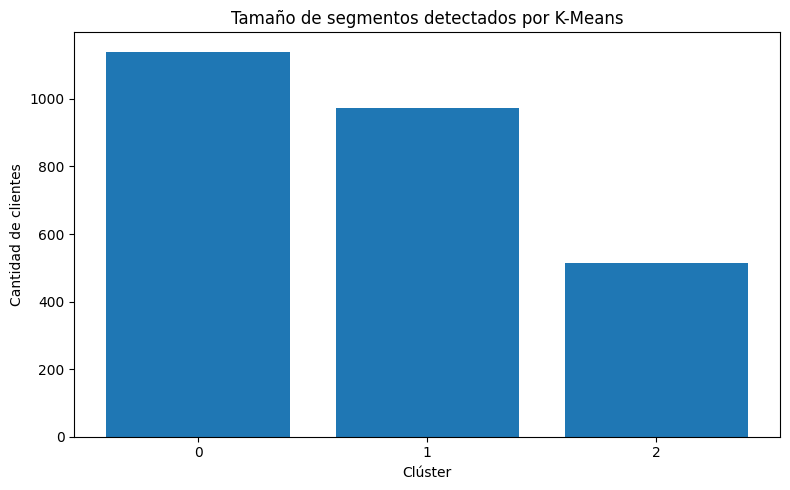


===== RECOMENDACIONES COMERCIALES =====


,cluster_kmeans,recomendacion_comercial
0,0,Clúster 0: orientar campañas de upselling y cr...
1,1,"Clúster 1: aplicar campañas de activación, pro..."
2,2,"Clúster 2: aplicar campañas de activación, pro..."



===== CONCLUSIÓN FINAL DE LA LECCIÓN 5 =====
El algoritmo con mejor desempeño cuantitativo fue K-Means, con una silueta de 0.1951 y 3 clúster(es).
En este proyecto, K-Means se adopta como segmentación principal por ofrecer la mejor relación entre calidad, estabilidad e interpretabilidad comercial.
El agrupamiento jerárquico aportó una estructura complementaria útil para la exploración, mientras que DBSCAN no logró una segmentación suficientemente informativa sobre este dataset.

===== ARCHIVOS GENERADOS =====
Archivo guardado: ../data/interim/perfil_segmentos_kmeans.csv
Archivo guardado: ../data/interim/consistencia_kmeans_vs_jerarquico.csv
Archivo guardado: ../data/interim/descripcion_segmentos_kmeans.csv
Archivo guardado: ../data/interim/recomendaciones_comerciales_segmentos.csv
Gráfico guardado: ../outputs/tamano_segmentos_kmeans.png


In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN
# =========================================================
RUTA_INTERIM = Path("../data/interim")
RUTA_OUTPUTS = Path("../outputs")
RUTA_INTERIM.mkdir(parents=True, exist_ok=True)
RUTA_OUTPUTS.mkdir(parents=True, exist_ok=True)

# Cargar archivos si no están en memoria
if "df_clusters" in globals():
    df_eval = df_clusters.copy()
else:
    df_eval = pd.read_csv(RUTA_INTERIM / "dataset_con_clusters_leccion4.csv")

if "resumen_algoritmos" in globals():
    resumen_modelos = resumen_algoritmos.copy()
else:
    resumen_modelos = pd.read_csv(RUTA_INTERIM / "resumen_algoritmos_clusterizacion.csv")

print("===== DIMENSIONES DEL DATASET CON CLÚSTERES =====")
print(df_eval.shape)

# =========================================================
# 1) PERFILAMIENTO DE SEGMENTOS K-MEANS
# =========================================================
# Variables numéricas disponibles para interpretar segmentos
variables_numericas_interpretacion = [
    col for col in ["Age", "Work_Experience", "Family_Size"]
    if col in df_eval.columns
]

perfil_numerico = (
    df_eval.groupby("cluster_kmeans")[variables_numericas_interpretacion]
    .mean()
    .round(3)
    .reset_index()
)

tamano_segmentos = (
    df_eval["cluster_kmeans"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_kmeans")
    .reset_index(name="cantidad_clientes")
)

tamano_segmentos["porcentaje"] = (
    tamano_segmentos["cantidad_clientes"] / tamano_segmentos["cantidad_clientes"].sum()
).round(4)

# Moda para variables categóricas
variables_categoricas_interpretacion = [
    col for col in ["Gender", "Ever_Married", "Graduated", "Profession", "Spending_Score", "Var_1"]
    if col in df_eval.columns
]

perfil_categorico = []
for cluster_id, subdf in df_eval.groupby("cluster_kmeans"):
    fila = {"cluster_kmeans": cluster_id}
    for col in variables_categoricas_interpretacion:
        moda = subdf[col].mode(dropna=True)
        fila[f"moda_{col}"] = moda.iloc[0] if not moda.empty else np.nan
    perfil_categorico.append(fila)

perfil_categorico = pd.DataFrame(perfil_categorico)

perfil_segmentos = (
    tamano_segmentos
    .merge(perfil_numerico, on="cluster_kmeans", how="left")
    .merge(perfil_categorico, on="cluster_kmeans", how="left")
    .sort_values("cluster_kmeans")
)

print("\n===== PERFIL DE SEGMENTOS K-MEANS =====")
display(perfil_segmentos)

perfil_segmentos.to_csv(RUTA_INTERIM / "perfil_segmentos_kmeans.csv", index=False)

# =========================================================
# 2) CONSISTENCIA ENTRE K-MEANS Y JERÁRQUICO
# =========================================================
tabla_consistencia = pd.crosstab(
    df_eval["cluster_kmeans"],
    df_eval["cluster_jerarquico"],
    margins=True
)

print("\n===== TABLA DE CONSISTENCIA K-MEANS VS JERÁRQUICO =====")
display(tabla_consistencia)

tabla_consistencia.to_csv(RUTA_INTERIM / "consistencia_kmeans_vs_jerarquico.csv")

# =========================================================
# 3) RESUMEN NARRATIVO AUTOMÁTICO DE SEGMENTOS
# =========================================================
descripciones_segmentos = []

for _, fila in perfil_segmentos.iterrows():
    cluster_id = int(fila["cluster_kmeans"])
    porcentaje = fila["porcentaje"] * 100

    descripcion = (
        f"El clúster {cluster_id} concentra el {porcentaje:.1f}% de los clientes, "
        f"con edad promedio de {fila['Age']:.1f} años, experiencia laboral promedio de "
        f"{fila['Work_Experience']:.1f} y tamaño familiar promedio de {fila['Family_Size']:.1f}. "
        f"Su perfil modal corresponde a género {fila.get('moda_Gender', 'N/D')}, "
        f"estado civil previo {fila.get('moda_Ever_Married', 'N/D')}, "
        f"graduación {fila.get('moda_Graduated', 'N/D')}, "
        f"profesión {fila.get('moda_Profession', 'N/D')} y nivel de gasto "
        f"{fila.get('moda_Spending_Score', 'N/D')}."
    )

    descripciones_segmentos.append({
        "cluster_kmeans": cluster_id,
        "descripcion_segmento": descripcion
    })

df_descripciones = pd.DataFrame(descripciones_segmentos)

print("\n===== DESCRIPCIÓN NARRATIVA DE SEGMENTOS =====")
display(df_descripciones)

df_descripciones.to_csv(RUTA_INTERIM / "descripcion_segmentos_kmeans.csv", index=False)

# =========================================================
# 4) GRÁFICO DE TAMAÑO DE SEGMENTOS
# =========================================================
plt.figure(figsize=(8, 5))
plt.bar(
    perfil_segmentos["cluster_kmeans"].astype(str),
    perfil_segmentos["cantidad_clientes"]
)
plt.title("Tamaño de segmentos detectados por K-Means")
plt.xlabel("Clúster")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()
plt.savefig(RUTA_OUTPUTS / "tamano_segmentos_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 5) RECOMENDACIONES COMERCIALES AUTOMÁTICAS
# =========================================================
recomendaciones = []

for _, fila in perfil_segmentos.iterrows():
    cluster_id = int(fila["cluster_kmeans"])
    spending = fila.get("moda_Spending_Score", np.nan)
    edad = fila.get("Age", np.nan)
    familia = fila.get("Family_Size", np.nan)

    if spending == "High":
        recomendacion = (
            f"Clúster {cluster_id}: enfocar estrategias de fidelización premium, "
            f"beneficios exclusivos y campañas de retención para clientes de alto valor."
        )
    elif spending == "Average":
        recomendacion = (
            f"Clúster {cluster_id}: orientar campañas de upselling y cross-selling, "
            f"buscando elevar el valor promedio del segmento."
        )
    else:
        recomendacion = (
            f"Clúster {cluster_id}: aplicar campañas de activación, promociones específicas "
            f"y estrategias de conversión para incrementar el gasto."
        )

    if pd.notna(edad) and edad < 35:
        recomendacion += " El perfil relativamente más joven sugiere canales digitales y comunicación más dinámica."
    elif pd.notna(edad) and edad >= 50:
        recomendacion += " El perfil de mayor edad sugiere comunicación más personalizada y propuestas de valor claras."

    if pd.notna(familia) and familia >= 3:
        recomendacion += " El tamaño familiar relativamente alto permite explorar ofertas familiares o paquetes conjuntos."

    recomendaciones.append({
        "cluster_kmeans": cluster_id,
        "recomendacion_comercial": recomendacion
    })

df_recomendaciones = pd.DataFrame(recomendaciones)

print("\n===== RECOMENDACIONES COMERCIALES =====")
display(df_recomendaciones)

df_recomendaciones.to_csv(RUTA_INTERIM / "recomendaciones_comerciales_segmentos.csv", index=False)

# =========================================================
# 6) CONCLUSIÓN AUTOMÁTICA DEL MODELO
# =========================================================
mejor_modelo = resumen_modelos.sort_values(
    by=["silhouette", "n_clusters"],
    ascending=[False, True]
).iloc[0]

print("\n===== CONCLUSIÓN FINAL DE LA LECCIÓN 5 =====")
print(
    f"El algoritmo con mejor desempeño cuantitativo fue {mejor_modelo['algoritmo']}, "
    f"con una silueta de {mejor_modelo['silhouette']:.4f} y {int(mejor_modelo['n_clusters'])} clúster(es)."
)
print(
    "En este proyecto, K-Means se adopta como segmentación principal por ofrecer "
    "la mejor relación entre calidad, estabilidad e interpretabilidad comercial."
)
print(
    "El agrupamiento jerárquico aportó una estructura complementaria útil para la exploración, "
    "mientras que DBSCAN no logró una segmentación suficientemente informativa sobre este dataset."
)

print("\n===== ARCHIVOS GENERADOS =====")
print("Archivo guardado: ../data/interim/perfil_segmentos_kmeans.csv")
print("Archivo guardado: ../data/interim/consistencia_kmeans_vs_jerarquico.csv")
print("Archivo guardado: ../data/interim/descripcion_segmentos_kmeans.csv")
print("Archivo guardado: ../data/interim/recomendaciones_comerciales_segmentos.csv")
print("Gráfico guardado: ../outputs/tamano_segmentos_kmeans.png")

### Hallazgos de la Lección 5

En esta etapa se compararon las segmentaciones obtenidas y se evaluó su consistencia general. Los resultados mostraron que K-Means ofrece la solución más equilibrada entre calidad cuantitativa, estabilidad e interpretabilidad comercial, por lo que se adoptó como modelo principal de segmentación. El agrupamiento jerárquico permitió reforzar parcialmente la estructura observada, mientras que DBSCAN no logró identificar una partición suficientemente útil para este conjunto de datos.

A partir del modelo principal se construyeron perfiles de segmento utilizando variables numéricas y categóricas relevantes, lo que permitió interpretar cada clúster como un grupo de clientes con características diferenciadas. Sobre esa base, se propusieron recomendaciones accionables orientadas a retención, fidelización, activación comercial y ventas cruzadas, cumpliendo así el objetivo de traducir el análisis no supervisado en decisiones útiles para el negocio.